In [ ]:
import numpy as np
import pandas as pd

In [ ]:
house=pd.read_csv("/content/housing.csv")
tr = pd.read_csv("/content/test_Y3wMUE5_7gLdaTN.csv")
ts = pd.read_csv("/content/train_u6lujuX_CVtuZ9i.csv")
Sp=pd.read_csv("/content/Student_performance_data _.csv")

In [ ]:
house.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
Sp.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Quick overview
print("Dataset Shape:", Sp.shape)
print("\nFirst 5 rows:")
print(Sp.head())
print("\nColumn Names:")
print(Sp.columns.tolist())
print("\nData Types:")
print(Sp.dtypes)

Dataset Shape: (2392, 15)

First 5 rows:
   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  

In [ ]:
# Statistical summary
print("\nStatistical Summary:")
print(Sp.describe())




Statistical Summary:
         StudentID          Age       Gender    Ethnicity  ParentalEducation  \
count  2392.000000  2392.000000  2392.000000  2392.000000        2392.000000   
mean   2196.500000    16.468645     0.510870     0.877508           1.746237   
std     690.655244     1.123798     0.499986     1.028476           1.000411   
min    1001.000000    15.000000     0.000000     0.000000           0.000000   
25%    1598.750000    15.000000     0.000000     0.000000           1.000000   
50%    2196.500000    16.000000     1.000000     0.000000           2.000000   
75%    2794.250000    17.000000     1.000000     2.000000           2.000000   
max    3392.000000    18.000000     1.000000     3.000000           4.000000   

       StudyTimeWeekly     Absences     Tutoring  ParentalSupport  \
count      2392.000000  2392.000000  2392.000000      2392.000000   
mean          9.771992    14.541388     0.301421         2.122074   
std           5.652774     8.467417     0.458971  

In [ ]:
# Drop ID
Sp_clean = Sp.drop('StudentID', axis=1)

# For predicting GPA, drop GradeClass (otherwise target leakage)
Sp_clean = Sp_clean.drop('GradeClass', axis=1)

In [ ]:
# Check missing values
print(Sp_clean.isnull().sum())

# For simplicity, drop rows with any missing (or impute)
Sp_clean = Sp_clean.dropna()

Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
dtype: int64


In [ ]:
categorical_cols = ['Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring',
                    'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

# LabelEncoder for binary or ordinal categories (if they have order)
# For simplicity, use One-Hot Encoding
Sp_encoded = pd.get_dummies(Sp_clean, columns=categorical_cols, drop_first=True)

In [ ]:
Sp_encoded

,Age,StudyTimeWeekly,Absences,GPA,Gender_1,Ethnicity_1,Ethnicity_2,Ethnicity_3,ParentalEducation_1,ParentalEducation_2,...,ParentalEducation_4,Tutoring_1,ParentalSupport_1,ParentalSupport_2,ParentalSupport_3,ParentalSupport_4,Extracurricular_1,Sports_1,Music_1,Volunteering_1
0,17,19.833723,7,2.929196,True,False,False,False,False,True,...,False,True,False,True,False,False,False,False,True,False
1,18,15.408756,0,3.042915,False,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
2,15,4.210570,26,0.112602,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,17,10.028829,14,2.054218,True,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,17,4.672495,17,1.288061,True,False,False,False,False,True,...,False,True,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,18,10.680555,2,3.455509,True,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
2388,17,7.583217,4,3.279150,False,False,False,False,True,False,...,False,True,False,False,False,True,False,True,False,False
2389,16,6.805500,20,1.142333,True,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2390,16,12.416653,17,1.803297,True,True,False,False,False,False,...,False,False,False,True,False,False,False,True,True,False


In [ ]:
X = Sp_encoded.drop('GPA', axis=1)
y = Sp_encoded['GPA']

In [ ]:
numerical_features = ['Age', 'StudyTimeWeekly', 'Absences']
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])

In [ ]:
# Correlation with GPA
correlations = X.corrwith(y).abs().sort_values(ascending=False)
print("Top features by correlation:")
print(correlations.head(10))

# Select features with correlation > 0.1 (adjust threshold)
selected_features = correlations[correlations > 0.1].index.tolist()
X_selected = X[selected_features]
print(f"\nSelected features: {selected_features}")

Top features by correlation:
Absences               0.919314
StudyTimeWeekly        0.179275
Tutoring_1             0.145119
ParentalSupport_4      0.107498
ParentalSupport_3      0.095472
Extracurricular_1      0.094078
ParentalSupport_1      0.083374
Music_1                0.073318
Sports_1               0.057859
ParentalEducation_3    0.045181
dtype: float64

Selected features: ['Absences', 'StudyTimeWeekly', 'Tutoring_1', 'ParentalSupport_4']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y,
                                                    test_size=0.2,
                                                    random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (1913, 4), Test size: (479, 4)


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [ ]:
dt = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name:20} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2}

results = []
results.append(evaluate(y_test, y_pred_lr, "Linear Regression"))
results.append(evaluate(y_test, y_pred_dt, "Decision Tree"))
results.append(evaluate(y_test, y_pred_rf, "Random Forest"))

# Compare
results_df = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(results_df.to_string(index=False))

Linear Regression    | RMSE: 0.2883 | MAE: 0.2257 | R²: 0.8995
Decision Tree        | RMSE: 0.3465 | MAE: 0.2788 | R²: 0.8548
Random Forest        | RMSE: 0.3072 | MAE: 0.2391 | R²: 0.8858

=== Model Comparison ===
            Model     RMSE      MAE       R²
Linear Regression 0.288304 0.225672 0.899485
    Decision Tree 0.346530 0.278813 0.854785
    Random Forest 0.307245 0.239097 0.885844


In [ ]:
cv_r2 = cross_val_score(rf, X_selected, y, cv=5, scoring='r2')
print(f"Random Forest 5-fold CV R²: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")

Random Forest 5-fold CV R²: 0.8906 (+/- 0.0064)


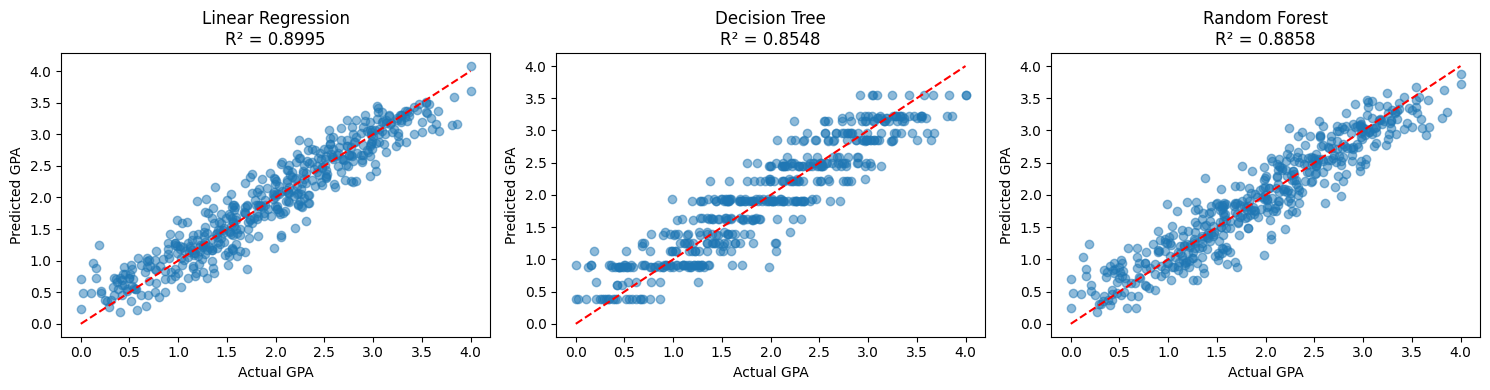

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [(y_pred_lr, 'Linear Regression'), (y_pred_dt, 'Decision Tree'), (y_pred_rf, 'Random Forest')]

for ax, (pred, name) in zip(axes, models):
    ax.scatter(y_test, pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    ax.set_xlabel('Actual GPA')
    ax.set_ylabel('Predicted GPA')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, pred):.4f}')

plt.tight_layout()
plt.show()

In [ ]:
# Re-load data or use original df
X_class = Sp.drop(['StudentID', 'GPA'], axis=1)   # remove GPA to avoid leakage
y_class = Sp['GradeClass']

# Encode categorical features (same as before)
X_class_encoded = pd.get_dummies(X_class, columns=categorical_cols, drop_first=True)

# Label encode target
le = LabelEncoder()
y_class_encoded = le.fit_transform(y_class)  # e.g., 0=A,1=B,...

# Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class_encoded, y_class_encoded, test_size=0.2, random_state=42)

# Use Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
y_pred_c = rf_clf.predict(X_test_c)

print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.4f}")
print(classification_report(y_test_c, y_pred_c, target_names=[str(cls) for cls in le.classes_]))

Accuracy: 0.9770
              precision    recall  f1-score   support

         0.0       1.00      0.50      0.67        22
         1.0       0.82      1.00      0.90        49
         2.0       1.00      1.00      1.00        85
         3.0       1.00      1.00      1.00        86
         4.0       1.00      1.00      1.00       237

    accuracy                           0.98       479
   macro avg       0.96      0.90      0.91       479
weighted avg       0.98      0.98      0.97       479

